In [16]:
from lm_polygraph.utils import UEManager


# Load managers with_labels

# base_path = '/l/users/maiya.goloburda/why_dk'
# base_path = '/l/users/maiya.goloburda/why_dk/with_labels/with_semantic'

# base_path = '/l/users/maiya.goloburda/why_dk/with_labels/with_verbalized'
base_path = 'results'

# model='gemma12bit'
# model = 'gpt_4.1'

model = 'llama_3.3_70b'
# model ='qwen'
man_single = UEManager.load(f'{base_path}/single_{model}.man')

man_multi = UEManager.load(f'{base_path}/multi_{model}.man')

man_ambi = UEManager.load(f'{base_path}/ambi_{model}.man')




{'obj': 'InitialStateCalculator'}
{'obj': 'RawInputCalculator'}
{'nli_model': {'deberta_path': 'microsoft/deberta-large-mnli', 'hf_cache': None, 'batch_size': 10, 'device': None}, 'obj': 'SemanticMatrixCalculator'}
{'nli_model': {'deberta_path': 'microsoft/deberta-large-mnli', 'hf_cache': None, 'batch_size': 10, 'device': None}, 'obj': 'GreedySemanticMatrixCalculator'}
{'nli_model': {'deberta_path': 'microsoft/deberta-large-mnli', 'hf_cache': None, 'batch_size': 10, 'device': None}, 'obj': 'ConcatGreedySemanticMatrixCalculator'}
{'obj': 'SemanticClassesCalculator'}
all_layers False
{'output_attentions': True, 'output_hidden_states': True, 'all_layers': True, 'obj': 'GreedyProbsCalculator'}
{'obj': 'EntropyCalculator'}
{'obj': 'GreedyLMProbsCalculator'}
{'obj': 'PromptCalculator'}
{'obj': 'SamplingGenerationCalculator'}
{'obj': 'BartScoreCalculator'}
{'obj': 'ModelScoreCalculator'}
{'obj': 'EnsembleTokenLevelDataCalculator'}
{'obj': 'PromptCalculator'}
{'obj': 'SamplingPromptCalculator'

In [17]:
managers = {
    'Ambiguous input': man_ambi,
    'Multi-answer':    man_multi,
    'Single answer':   man_single,
}


In [18]:
import json

def load_labels(path):
    labels = []
    with open(path, "r") as f:
        for line in f:
            row = json.loads(line)
            labels.append(row["label"])
    return labels
base_path_labels ='/nfs-stor/statml/maiya/managers_source_ue'
managers = {
    'Ambiguous input': man_ambi,
    'Multi-answer':    man_multi,
    'Single answer':   man_single,
}
label_files = {
    'Ambiguous input': f"{base_path_labels}/annotations_ambi_{model}.jsonl",
    'Multi-answer':    f"{base_path_labels}/annotations_multi_{model}.jsonl",
    'Single answer':   f"{base_path_labels}/annotations_single_{model}.jsonl",
}
for scenario, man in managers.items():
    labels = load_labels(label_files[scenario])
    man.stats["labels"] = labels

def compute_decision_metric(manager, type):
    labels = manager.stats["labels"]       # list of labels
    n = len(labels)

    # 1 = correct
    # 0 = incorrect or answered (for Ambiguous)
    decisions = []
    for label in labels:
        if label == "correct" or (type=='Ambiguous input' and label == 'clarification'):
            decisions.append(1)
        else:  # "incorrect", "answered", etc.
            decisions.append(0)

    # Store inside manager.gen_metrics
    manager.gen_metrics[('sequence', 'decision')] = decisions

for scenario, man in managers.items():
    compute_decision_metric(man, scenario)


In [19]:
from lm_polygraph.estimators.cocoa import Consistency

estimator = Consistency()
for scenario, man in managers.items():
    man.estimations[('sequence', str(estimator))] = list(estimator(man.stats))

In [20]:
for scenario, man in managers.items():

    man.estimations[('sequence', 'UEVerbalized2S')] = [
        -x for x in man.estimations[('sequence', 'Verbalized2S')]
    ]

In [21]:
from collections import defaultdict
from types import SimpleNamespace

# managers = { 'Ambiguous input': man_ambi, 'Multi-answer': man_multi, 'Single answer': man_single }

# create an empty combined manager-like object
combined = SimpleNamespace(
    stats={},
    estimations=defaultdict(list),
    metrics=defaultdict(list),
    gen_metrics=defaultdict(list),
)

for scenario_name, man in managers.items():
    # ---- stats ----
    for key, value in man.stats.items():
        if isinstance(value, list):
            
            # per-generation list -> concatenate
            combined.stats.setdefault(key, []).extend(value)
        else:
            # scalar/statistic -> store per scenario
            combined.stats.setdefault(key, {})[scenario_name] = value

    # add scenario label per generation (based on labels length)
    n = len(man.stats["labels"])
    combined.stats.setdefault("scenario", []).extend([scenario_name] * n)

    # ---- estimations ----
    for key, values in man.estimations.items():         # key is ('sequence', method)
        combined.estimations[key].extend(values)

    # ---- metrics ----
    for key, value in man.metrics.items():
        if isinstance(value, list):
            combined.metrics[key].extend(value)
        else:
            combined.metrics.setdefault(key, {})[scenario_name] = value

    # ---- gen_metrics ----
    for key, value in man.gen_metrics.items():
        if isinstance(value, list):
            combined.gen_metrics[key].extend(value)
        else:
            combined.gen_metrics.setdefault(key, {})[scenario_name] = value


In [22]:
from collections import defaultdict
from types import SimpleNamespace

managers_single_ambi = { 'Ambiguous input': man_ambi, 'Single answer': man_single }

# create an empty combined manager-like object
single_ambi = SimpleNamespace(
    stats={},
    estimations=defaultdict(list),
    metrics=defaultdict(list),
    gen_metrics=defaultdict(list),
)

for scenario_name, man in managers_single_ambi.items():
    # ---- stats ----
    for key, value in man.stats.items():
        if isinstance(value, list):
            
            # per-generation list -> concatenate
            single_ambi.stats.setdefault(key, []).extend(value)
        else:
            # scalar/statistic -> store per scenario
            single_ambi.stats.setdefault(key, {})[scenario_name] = value

    # add scenario label per generation (based on labels length)
    n = len(man.stats["labels"])
    single_ambi.stats.setdefault("scenario", []).extend([scenario_name] * n)

    # ---- estimations ----
    for key, values in man.estimations.items():         # key is ('sequence', method)
        single_ambi.estimations[key].extend(values)

    # ---- metrics ----
    for key, value in man.metrics.items():
        if isinstance(value, list):
            single_ambi.metrics[key].extend(value)
        else:
            single_ambi.metrics.setdefault(key, {})[scenario_name] = value

    # ---- gen_metrics ----
    for key, value in man.gen_metrics.items():
        if isinstance(value, list):
            single_ambi.gen_metrics[key].extend(value)
        else:
            single_ambi.gen_metrics.setdefault(key, {})[scenario_name] = value


In [23]:
import copy

order = ['Ambiguous input', 'Multi-answer', 'Single answer']

base_name = order[0]
combined = copy.deepcopy(managers[base_name])  # start from first manager

n_base = len(combined.stats["labels"])
combined.stats["scenario"] = [base_name] * n_base  # per-generation scenario label
def ensure_scenario_dict(stats_or_metrics, key, scenario_name):
    """Turn a scalar value into {scenario_name: value} if needed."""
    val = stats_or_metrics.get(key)
    if isinstance(val, dict):
        return
    stats_or_metrics[key] = {scenario_name: val}

for k, v in list(combined.stats.items()):
    if not isinstance(v, list) and k != "scenario":
        ensure_scenario_dict(combined.stats, k, base_name)

for k, v in list(combined.metrics.items()):
    if not isinstance(v, list):
        ensure_scenario_dict(combined.metrics, k, base_name)

for k, v in list(combined.gen_metrics.items()):
    if not isinstance(v, list):
        ensure_scenario_dict(combined.gen_metrics, k, base_name)

def append_manager(combined, other, other_name):
    # --- stats ---
    n_other = len(other.stats["labels"])
    combined.stats["scenario"].extend([other_name] * n_other)

    for key, val in other.stats.items():
        if key == "scenario":
            continue
        if isinstance(val, list):
            combined.stats.setdefault(key, [])
            combined.stats[key].extend(val)
        else:
            # per-scenario scalar
            ensure_scenario_dict(combined.stats, key, other_name)
            combined.stats[key][other_name] = val

    # --- estimations ---
    for key, vals in other.estimations.items():  # key is ('sequence', method)
        combined.estimations.setdefault(key, [])
        combined.estimations[key].extend(vals)

    # --- metrics ---
    for key, val in other.metrics.items():
        if isinstance(val, list):
            combined.metrics.setdefault(key, [])
            combined.metrics[key].extend(val)
        else:
            ensure_scenario_dict(combined.metrics, key, other_name)
            combined.metrics[key][other_name] = val

    # --- gen_metrics ---
    for key, val in other.gen_metrics.items():
        if isinstance(val, list):
            combined.gen_metrics.setdefault(key, [])
            combined.gen_metrics[key].extend(val)
        else:
            ensure_scenario_dict(combined.gen_metrics, key, other_name)
            combined.gen_metrics[key][other_name] = val
for name in order[1:]:
    append_manager(combined, managers[name], name)


In [24]:
import copy

order = ['Ambiguous input','Single answer']

base_name = order[0]
single_ambi = copy.deepcopy(managers_single_ambi[base_name])  # start from first manager

n_base = len(single_ambi.stats["labels"])
single_ambi.stats["scenario"] = [base_name] * n_base  # per-generation scenario label
def ensure_scenario_dict(stats_or_metrics, key, scenario_name):
    """Turn a scalar value into {scenario_name: value} if needed."""
    val = stats_or_metrics.get(key)
    if isinstance(val, dict):
        return
    stats_or_metrics[key] = {scenario_name: val}

for k, v in list(single_ambi.stats.items()):
    if not isinstance(v, list) and k != "scenario":
        ensure_scenario_dict(single_ambi.stats, k, base_name)

for k, v in list(single_ambi.metrics.items()):
    if not isinstance(v, list):
        ensure_scenario_dict(single_ambi.metrics, k, base_name)

for k, v in list(single_ambi.gen_metrics.items()):
    if not isinstance(v, list):
        ensure_scenario_dict(single_ambi.gen_metrics, k, base_name)

def append_manager(single_ambi, other, other_name):
    # --- stats ---
    n_other = len(other.stats["labels"])
    single_ambi.stats["scenario"].extend([other_name] * n_other)

    for key, val in other.stats.items():
        if key == "scenario":
            continue
        if isinstance(val, list):
            single_ambi.stats.setdefault(key, [])
            single_ambi.stats[key].extend(val)
        else:
            # per-scenario scalar
            ensure_scenario_dict(combined.stats, key, other_name)
            single_ambi.stats[key][other_name] = val

    # --- estimations ---
    for key, vals in other.estimations.items():  # key is ('sequence', method)
        single_ambi.estimations.setdefault(key, [])
        single_ambi.estimations[key].extend(vals)

    # --- metrics ---
    # for key, val in other.metrics.items():
    #     if isinstance(val, list):
    #         single_ambi.metrics.setdefault(key, [])
    #         single_ambi.metrics[key].extend(val)
    #     else:
    #         ensure_scenario_dict(combined.metrics, key, other_name)
    #         single_ambi.metrics[key][other_name] = val

    # --- gen_metrics ---
    for key, val in other.gen_metrics.items():
        if isinstance(val, list):
            single_ambi.gen_metrics.setdefault(key, [])
            single_ambi.gen_metrics[key].extend(val)
        else:
            ensure_scenario_dict(combined.gen_metrics, key, other_name)
            single_ambi.gen_metrics[key][other_name] = val
for name in order[1:]:
    append_manager(single_ambi, managers_single_ambi[name], name)


In [25]:
from lm_polygraph.ue_metrics import PredictionRejectionArea

ue_metrics = [PredictionRejectionArea(max_rejection=0.5), PredictionRejectionArea(), PredictionRejectionArea(max_rejection=0.75)]
combined.ue_metrics =ue_metrics
combined.eval_ue()

We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2

In [26]:
from lm_polygraph.ue_metrics import PredictionRejectionArea

ue_metrics = [PredictionRejectionArea(max_rejection=0.5), PredictionRejectionArea(), PredictionRejectionArea(max_rejection=0.75)]
single_ambi.ue_metrics =ue_metrics
single_ambi.eval_ue()

We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2

In [27]:
combined.metrics[('sequence', 'MaximumSequenceProbability', 'decision', 'prr_0.5_normalized')]

0.3836058400470155

In [28]:
ue_metrics = [PredictionRejectionArea(max_rejection=0.5), PredictionRejectionArea(), PredictionRejectionArea(max_rejection=0.75)]
man_single.ue_metrics =ue_metrics
man_single.eval_ue()

man_multi.ue_metrics =ue_metrics
man_multi.eval_ue()

man_ambi.ue_metrics =ue_metrics
man_ambi.eval_ue()

We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2

In [29]:
import pandas as pd

def extract_prr(metrics, max_rejection = None):
    rows = []
    for key, value in metrics.items():
        if max_rejection:
            if (
                isinstance(key, tuple)
                and len(key) == 4
                and key[0] == "sequence"
                and key[2] == "decision"
                and key[3] == f"prr_{max_rejection}_normalized"
            ):
                method = key[1]
                rows.append({"method": method, "prr": float(value)})
        else:
            if (
                isinstance(key, tuple)
                and len(key) == 4
                and key[0] == "sequence"
                and key[2] == "decision"
                and key[3] == "prr_normalized"
            ):
                method = key[1]
                rows.append({"method": method, "prr": float(value)})

    df = pd.DataFrame(rows).set_index("method")
    return df["prr"]

mrs = [0.5 , 0.75, None]

for mr in mrs:
    s_combined = extract_prr(combined.metrics, max_rejection=mr).rename("combined")
    s_multi    = extract_prr(man_multi.metrics, max_rejection=mr).rename("multi")
    s_single   = extract_prr(man_single.metrics, max_rejection=mr).rename("single")
    s_single_ambi   = extract_prr(single_ambi.metrics, max_rejection=mr).rename("single_ambi")

    df = pd.concat([
    s_single.rename("prr").to_frame().assign(type="single"),
    s_multi.rename("prr").to_frame().assign(type="multi"),
    s_combined.rename("prr").to_frame().assign(type="combined"),
    s_single_ambi.rename("prr").to_frame().assign(type="single_ambi")
], axis=0)

    # df = df.reset_index().rename(columns={"index": "method"})

    filename = f"results/{model}_prr_results_{mr}_reject_with_NLI_and_verb.csv"
    df["method"] = df.index
    df.to_csv(filename, index=False)
    print("Saved to:", filename)


Saved to: results/llama_3.3_70b_prr_results_0.5_reject_with_NLI_and_verb.csv
Saved to: results/llama_3.3_70b_prr_results_0.75_reject_with_NLI_and_verb.csv
Saved to: results/llama_3.3_70b_prr_results_None_reject_with_NLI_and_verb.csv


In [19]:
import numpy as np 
np.mean(man_ambi.gen_metrics[('sequence', 'decision')])



0.0

In [51]:
import pandas as pd

# ---------- 1. Load and pivot each model ----------

def load_model_table(csv_path: str, model_label: str):
    """
    csv_path: path to CSV with columns [method, prr, type]
    model_label: label used in column MultiIndex (e.g. 'llama', 'mistral')
    """
    df = pd.read_csv(csv_path)  # expects: method, prr, type
    wide = df.pivot(index="method", columns="type", values="prr")

    # enforce column order: single, multi, combined
    wide = wide[["single", "multi", "combined"]]

    # MultiIndex columns: (model_label, type)
    wide.columns = pd.MultiIndex.from_product([[model_label],
                                               ["single", "multi", "combined"]])
    return wide

# Example usage: replace paths + labels as needed
t_llama   = load_model_table("results/llama8bit_prr_results_None_reject.csv",   "llama8bit")
t_gemma = load_model_table("results/gemma12bit_prr_results_None_reject.csv", "gemma12bit")
t_qwen = load_model_table("results/qwen3_prr_results_None_reject_new.csv", "qwen")
# ---------- 2. Combine side-by-side on 'method' ----------

combined = pd.concat([t_llama, t_gemma, t_qwen], axis=1)

# Optional: enforce metric order if you have one
metric_order = [
    "MaximumSequenceProbability",
    "Perplexity",
    "MeanTokenEntropy",
    "MeanPointwiseMutualInformation",
    # "MeanConditionalPointwiseMutualInformation",
    "MonteCarloSequenceEntropy",
    "MonteCarloNormalizedSequenceEntropy",
    # "ToeknSAR",

    "Consistency",
    "NumSemSets",
    "EigValLaplacian_NLI_score_entail",
    # "EigValLaplacian_NLI_score_contra",
    "EigValLaplacian_Jaccard_score",
    "DegMat_NLI_score_entail",
    # "DegMat_NLI_score_contra",
    "Eccentricity_NLI_score_entail",
    # "Eccentricity_NLI_score_contra",

    "SemanticEntropy",
    "LUQ",
    "SAR",
    "SemanticDensity",
    "CocoaMSP",
    "CocoaPPL",
    "CocoaMTE",

    "CCP",
    # "TokenSAR",
    "PTrue"
]

metric_pretty_name = {
    "MaximumSequenceProbability":"SP",
    "Perplexity" : "PPL",
    "MeanTokenEntropy" : "MTE",
    "MeanPointwiseMutualInformation" : "MPMI",
    "MeanConditionalPointwiseMutualInformation" :"MCPMI",
    "MonteCarloSequenceEntropy" :"MCSE",
    "MonteCarloNormalizedSequenceEntropy" : "MCNSE",
    "ToeknSAR":"TokenSAR",

    "NumSemSets": "NumSemSets",
    "EigValLaplacian_NLI_score_entail":"$\\text{EigValLaplacian}_{entail}$",
    "EigValLaplacian_NLI_score_contra":"$\\text{EigValLaplacian}_{contra}$",
    "EigValLaplacian_Jaccard_score":"$\\text{EigValLaplacian}_{Jaccard}$",
    "DegMat_NLI_score_entail":"$\\text{DegMat}_{entail}$",
    "DegMat_NLI_score_contra":"$\\text{DegMat}_{contra}$",
    "Eccentricity_NLI_score_entail":"$\\text{Eccentricity}_{entail}$",
    "Eccentricity_NLI_score_contra":"$\\text{Eccentricity}_{contra}$",

    "Consistency":"Consistency",
    "SemanticEntropy":"Semantic Entropy",
    "LUQ":"LUQ",
    "SAR":"SAR",
    "SemanticDensity":"Semantic Density",
    "CocoaMSP":"CocoaMSP",
    "CocoaPPL":"CocoaPPL",
    "CocoaMTE":"CocoaMTE",

    "CCP":"CCP",
    "PTrue":"P(True)",
}

combined = combined.reindex(metric_order).dropna(how="all")

# models + types in order
models = ["llama8bit", "gemma12bit", "qwen"]
types = ["single", "multi", "combined"]


# ---------- 3. (Optional) escape LaTeX specials in metric names ----------

def latex_escape(s: str) -> str:
    return (
        s.replace("\\", r"\textbackslash{}")
         .replace("_", r"\_")
         .replace("%", r"\%")
         .replace("&", r"\&")
         .replace("#", r"\#")
         .replace("{", r"\{")
         .replace("}", r"\}")
    )


# ---------- 4. Format best (bold) and second-best (underline) per column ----------

formatted = combined.copy().astype(object)  # make room for strings

for col in formatted.columns:  # col is like ('llama8bit', 'single')
    s = combined[col]
    s_nonan = s.dropna()

    if len(s_nonan) == 0:
        continue

    best_idx = s_nonan.idxmax()
    second_idx = s_nonan.drop(best_idx).idxmax() if len(s_nonan) > 1 else None

    for idx in combined.index:
        val = combined.loc[idx, col]
        if pd.isna(val):
            formatted.loc[idx, col] = ""
            continue

        txt = f"{val:.3f}"
        if idx == best_idx:
            formatted.loc[idx, col] = rf"\textbf{{{txt}}}"
        elif second_idx is not None and idx == second_idx:
            formatted.loc[idx, col] = rf"\underline{{{txt}}}"
        else:
            formatted.loc[idx, col] = txt


# ---------- 5. Build LaTeX body rows safely (no brace issues) ----------

rows = []
for metric, row in formatted.iterrows():   # use formatted, not combined
    if pd.isna(row).all():
        continue
    metric_name =  metric_pretty_name[metric] # latex_escape(metric)
    cells = [metric_name]
    for m in models:
        for t in types:
            cell = row[(m, t)]
            cells.append("" if pd.isna(cell) else str(cell))
    rows.append(" & ".join(cells) + r" \\")
body = "\n".join(rows)


# ---------- 6. Build the LaTeX header with multicolumns per model ----------

# column spec: 1 metric column + 3 per model
colspec = "l" + "ccc" * len(models)

# model names in header
model_headers = {
    "llama8bit": "Llama-8b-it",
    "gemma12bit": "Gemma-12b-it",
    "qwen": "Qwen-14b-it"
}

header_line1_parts = [r"\textbf{Metric}"]
for m in models:
    model_tex = model_headers[m]
    part = f"\\multicolumn{{3}}{{c}}{{\\textbf{{{model_tex}}}}}"
    header_line1_parts.append(part)
header_line1 = " & ".join(header_line1_parts) + r" \\"

# cmidrule lines
cmidrules = []
col_start = 2  # first model block starts at column 2
for _ in models:
    col_end = col_start + 2
    cmidrules.append(f"\\cmidrule(lr){{{col_start}-{col_end}}}")
    col_start = col_end + 1
cmidrule_line = " ".join(cmidrules)

# second header line: metric column is empty, then types for each model
second_header_cells = [""]
for _ in models:
    second_header_cells.extend([
        r"\textbf{single}",
        r"\textbf{multi}",
        r"\textbf{combined}",
    ])
second_header_line = " & ".join(second_header_cells) + r" \\"


# ---------- 7. Put everything together ----------

latex_table = (
    f"\\begin{{tabular}}{{{colspec}}}\n"
    "\\toprule\n"
    + header_line1 + "\n"
    + cmidrule_line + "\n"
    + second_header_line + "\n"
    "\\midrule\n"
    + body + "\n"
    "\\bottomrule\n"
    "\\end{tabular}"
)

print(latex_table)


\begin{tabular}{lccccccccc}
\toprule
\textbf{Metric} & \multicolumn{3}{c}{\textbf{Llama-8b-it}} & \multicolumn{3}{c}{\textbf{Gemma-12b-it}} & \multicolumn{3}{c}{\textbf{Qwen-14b-it}} \\
\cmidrule(lr){2-4} \cmidrule(lr){5-7} \cmidrule(lr){8-10}
 & \textbf{single} & \textbf{multi} & \textbf{combined} & \textbf{single} & \textbf{multi} & \textbf{combined} & \textbf{single} & \textbf{multi} & \textbf{combined} \\
\midrule
SP & 0.692 & 0.688 & 0.578 & 0.643 & 0.513 & 0.396 & -0.075 & -0.079 & 0.297 \\
PPL & 0.617 & 0.557 & 0.516 & 0.625 & 0.494 & 0.369 & -0.075 & -0.079 & 0.297 \\
MTE & 0.665 & 0.634 & 0.580 & 0.654 & 0.517 & 0.382 & \underline{-0.060} & -0.085 & \textbf{0.302} \\
MPMI & 0.360 & 0.432 & 0.274 & 0.242 & 0.092 & 0.212 & -0.075 & -0.079 & 0.297 \\
MCSE & 0.693 & \textbf{0.721} & \textbf{0.598} & 0.659 & 0.520 & 0.406 & -0.075 & -0.079 & 0.297 \\
MCNSE & 0.619 & 0.539 & 0.509 & 0.627 & 0.491 & 0.372 & -0.075 & -0.079 & 0.297 \\
Consistency & 0.599 & 0.528 & 0.455 & 0.473 & 0.48

In [30]:
import pandas as pd

# ---------- 1. Load model data ----------

def load_model_table(csv_path: str, model_label: str):
    df = pd.read_csv(csv_path)  # expects: method, prr, type
    wide = df.pivot(index="method", columns="type", values="prr")
    wide = wide[["single", "multi", "combined"]]
    return wide

df = load_model_table("results/llama_3.3_70b_prr_results_0.75_reject_with_NLI_and_verb.csv", "llama_3.3_70b")

# ---------- 2. Metric ordering and pretty names ----------

metric_order = [
    "MaximumSequenceProbability", "Perplexity", "MeanTokenEntropy",
    "MeanPointwiseMutualInformation", "MonteCarloSequenceEntropy",
    "MonteCarloNormalizedSequenceEntropy", "Consistency", "NumSemSets",
    "EigValLaplacian_NLI_score_entail", "EigValLaplacian_Jaccard_score",
    "DegMat_NLI_score_entail", "Eccentricity_NLI_score_entail",
    "SemanticEntropy", "LUQ", "SAR", "SemanticDensity",
    "CocoaMSP", "CocoaPPL", "CocoaMTE", "CCP", "PTrue", "UEVerbalized2S"
]

metric_pretty_name = {
    "MaximumSequenceProbability": "SP",
    "Perplexity": "PPL",
    "MeanTokenEntropy": "MTE",
    "MeanPointwiseMutualInformation": "MPMI",
    "MonteCarloSequenceEntropy": "MCSE",
    "MonteCarloNormalizedSequenceEntropy": "MCNSE",
    "Consistency": "Consistency",
    "NumSemSets": "NumSemSets",
    "EigValLaplacian_NLI_score_entail": "EigValLaplacian (entail)",
    "EigValLaplacian_Jaccard_score": "EigValLaplacian (Jaccard)",
    "DegMat_NLI_score_entail": "DegMat (entail)",
    "Eccentricity_NLI_score_entail": "Eccentricity (entail)",
    "SemanticEntropy": "Semantic Entropy",
    "LUQ": "LUQ",
    "SAR": "SAR",
    "SemanticDensity": "Semantic Density",
    "CocoaMSP": "CocoaMSP",
    "CocoaPPL": "CocoaPPL",
    "CocoaMTE": "CocoaMTE",
    "CCP": "CCP",
    "PTrue": "P(True)",
    "UEVerbalized2S":"Verbalized2s"
}

df = df.reindex(metric_order).dropna(how="all")

# ---------- 3. Find best and second-best per column ----------

def format_cell(val, is_best, is_second):
    if pd.isna(val):
        return ""
    txt = f"{val:.3f}"
    if is_best:
        return f"**{txt}**"
    if is_second:
        return f"_{txt}_"
    return txt

# ---------- 4. Build markdown table ----------

header = "| Metric | Single | Multi | Combined |"
separator = "|--------|--------|-------|----------|"

rows = [header, separator]

for col in ["single", "multi", "combined"]:
    s = df[col].dropna()
    if len(s) == 0:
        continue
    best_idx = s.idxmax()
    second_idx = s.drop(best_idx).idxmax() if len(s) > 1 else None

    # Store per-column bests for use in row building
    df.loc[best_idx, f"_best_{col}"] = True
    if second_idx:
        df.loc[second_idx, f"_second_{col}"] = True

for metric in df.index:
    row_data = df.loc[metric]
    pretty = metric_pretty_name.get(metric, metric)
    cells = [pretty]
    for col in ["single", "multi", "combined"]:
        val = df.loc[metric, col] if col in df.columns else float("nan")
        is_best   = df.loc[metric].get(f"_best_{col}",   False) == True
        is_second = df.loc[metric].get(f"_second_{col}", False) == True
        cells.append(format_cell(val, is_best, is_second))
    rows.append("| " + " | ".join(cells) + " |")

print("\n".join(rows))


| Metric | Single | Multi | Combined |
|--------|--------|-------|----------|
| SP | 0.656 | 0.274 | 0.381 |
| PPL | 0.598 | 0.239 | 0.348 |
| MTE | 0.628 | 0.230 | 0.356 |
| MCSE | 0.718 | **0.313** | **0.416** |
| MCNSE | 0.639 | 0.238 | 0.328 |
| Consistency | 0.581 | 0.189 | 0.287 |
| NumSemSets | 0.627 | 0.166 | 0.308 |
| EigValLaplacian (entail) | _0.739_ | 0.204 | 0.356 |
| DegMat (entail) | 0.714 | 0.216 | 0.345 |
| Eccentricity (entail) | 0.697 | 0.266 | 0.373 |
| Semantic Entropy | 0.711 | _0.308_ | _0.410_ |
| Semantic Density | **0.784** | 0.244 | 0.400 |
| CocoaMSP | 0.660 | 0.261 | 0.363 |
| CocoaPPL | 0.628 | 0.232 | 0.343 |
| CocoaMTE | 0.650 | 0.225 | 0.345 |
| Verbalized2s | 0.701 | 0.025 | 0.301 |


In [7]:
import pandas as pd

# ---------- 1. Load and pivot each model ----------

def load_model_table(csv_path: str, model_label: str):
    """
    csv_path: path to CSV with columns [method, prr, type]
    model_label: label used in column MultiIndex (e.g. 'llama', 'mistral')
    """
    df = pd.read_csv(csv_path)  # expects: method, prr, type
    wide = df.pivot(index="method", columns="type", values="prr")

    # desired types, including single_ambi
    desired_types = ["single", "single_ambi", "multi", "combined"]
    # use reindex so it works even if some types are missing in this file
    wide = wide.reindex(columns=desired_types)

    # MultiIndex columns: (model_label, type)
    wide.columns = pd.MultiIndex.from_product(
        [[model_label], desired_types]
    )
    return wide

# Example usage: replace paths + labels as needed
t_llama = load_model_table("results/llama8bit_prr_results_0.75_reject_with_NLI_and_verb.csv", "llama8bit")
t_gemma = load_model_table("results/gemma12bit_prr_results_0.75_reject_with_NLI_and_verb.csv", "gemma12bit")
t_qwen  = load_model_table("results/qwen14bit_prr_results_0.75_reject_with_NLI_and_verb.csv",      "qwen14bit")

# ---------- 2. Combine side-by-side on 'method' ----------

combined = pd.concat([t_llama, t_gemma, t_qwen], axis=1)

# Optional: enforce metric order if you have one
metric_order = [
    "MaximumSequenceProbability",
    "Perplexity",
    "MeanTokenEntropy",
    "MeanPointwiseMutualInformation",
    # "MeanConditionalPointwiseMutualInformation",
    "MonteCarloSequenceEntropy",
    "MonteCarloNormalizedSequenceEntropy",
    # "ToeknSAR",

    "Consistency",
    # "NLIConsistency",
    "NumSemSets",
    "EigValLaplacian_NLI_score_entail",
    # "EigValLaplacian_NLI_score_contra",
    "EigValLaplacian_Jaccard_score",
    "DegMat_NLI_score_entail",
    # "DegMat_NLI_score_contra",
    "Eccentricity_NLI_score_entail",
    # "Eccentricity_NLI_score_contra",

    "SemanticEntropy",
    "LUQ",
    "SAR",
    "SemanticDensity",
    "CocoaMSP",
    "CocoaPPL",
    "CocoaMTE",
    # "NLICocoaMSP",
    # "NLICocoaPPL",
    # "NLICocoaMTE",

    # "CCP",
    # "TokenSAR",
    "PTrue",
    'UEVerbalized2S'
]

metric_pretty_name = {
    "MaximumSequenceProbability": "SP",
    "Perplexity": "PPL",
    "MeanTokenEntropy": "MTE",
    "MeanPointwiseMutualInformation": "MPMI",
    "MeanConditionalPointwiseMutualInformation": "MCPMI",
    "MonteCarloSequenceEntropy": "MCSE",
    "MonteCarloNormalizedSequenceEntropy": "MCNSE",
    "ToeknSAR": "TokenSAR",

    "NumSemSets": "NumSemSets",
    "EigValLaplacian_NLI_score_entail": r"$\text{EigValLaplacian}_{entail}$",
    "EigValLaplacian_NLI_score_contra": r"$\text{EigValLaplacian}_{contra}$",
    "EigValLaplacian_Jaccard_score": r"$\text{EigValLaplacian}_{Jaccard}$",
    "DegMat_NLI_score_entail": r"$\text{DegMat}_{entail}$",
    "DegMat_NLI_score_contra": r"$\text{DegMat}_{contra}$",
    "Eccentricity_NLI_score_entail": r"$\text{Eccentricity}_{entail}$",
    "Eccentricity_NLI_score_contra": r"$\text{Eccentricity}_{contra}$",

    "Consistency": "Consistency",
        "NLIConsistency": "NLI_ConsistencyNLI",
    "SemanticEntropy": "Semantic Entropy",
    "LUQ": "LUQ",
    "SAR": "SAR",
    "SemanticDensity": "Semantic Density",
    "CocoaMSP": "CocoaMSP",
    "CocoaPPL": "CocoaPPL",
    "CocoaMTE": "CocoaMTE",
    "NLICocoaMSP": "NLICocoaMSP",
    "NLICocoaPPL": "NLICocoaPPL",
    "NLICocoaMTE": "NLICocoaMTE",
    "UEVerbalized2S":"Verbalized2S",
    "CCP": "CCP",
    "PTrue": "P(True)",
}

combined = combined.reindex(metric_order).dropna(how="all")

# models + types in order
models = ["llama8bit", "gemma12bit", "qwen14bit"]
types = ["single", "single_ambi", "multi", "combined"]


# ---------- 3. (Optional) escape LaTeX specials in metric names ----------

def latex_escape(s: str) -> str:
    return (
        s.replace("\\", r"\textbackslash{}")
         .replace("_", r"\_")
         .replace("%", r"\%")
         .replace("&", r"\&")
         .replace("#", r"\#")
         .replace("{", r"\{")
         .replace("}", r"\}")
    )


# ---------- 4. Format best (bold) and second-best (underline) per column ----------
# Also: if a model doesn't have a value for a type, show '---'.

formatted = combined.copy().astype(object)  # make room for strings

for col in formatted.columns:  # col is like ('llama8bit', 'single')
    s = combined[col]
    s_nonan = s.dropna()

    # No non-NaN values at all in this column → everything becomes '---'
    if len(s_nonan) == 0:
        for idx in combined.index:
            formatted.loc[idx, col] = r"---"
        continue

    best_idx = s_nonan.idxmax()
    second_idx = s_nonan.drop(best_idx).idxmax() if len(s_nonan) > 1 else None

    for idx in combined.index:
        val = combined.loc[idx, col]
        if pd.isna(val):
            # Missing in this model/type → '---'
            formatted.loc[idx, col] = r"---"
            continue

        txt = f"{val:.3f}"
        if idx == best_idx:
            formatted.loc[idx, col] = rf"\textbf{{{txt}}}"
        elif second_idx is not None and idx == second_idx:
            formatted.loc[idx, col] = rf"\underline{{{txt}}}"
        else:
            formatted.loc[idx, col] = txt


# ---------- 5. Build LaTeX body rows ----------

rows = []
for metric, row in formatted.iterrows():   # use formatted, not combined
    # skip rows that are entirely missing (shouldn't happen after dropna(how="all"))
    if all((str(x) == "nan" for x in row)):
        continue

    metric_name = metric_pretty_name[metric]
    cells = [metric_name]
    for m in models:
        for t in types:
            cell = row[(m, t)]
            cells.append(str(cell))
    rows.append(" & ".join(cells) + r" \\")
body = "\n".join(rows)


# ---------- 6. Build the LaTeX header with multicolumns per model ----------

# column spec: 1 metric column + 4 per model
colspec = "l" + "cccc" * len(models)

# model names in header
model_headers = {
    "llama8bit": "Llama-8b-it",
    "gemma12bit": "Gemma-12b-it",
    "qwen14bit": "Qwen-14b-it"
}

header_line1_parts = [r"\textbf{Metric}"]
for m in models:
    model_tex = model_headers[m]
    part = f"\\multicolumn{{4}}{{c}}{{\\textbf{{{model_tex}}}}}"
    header_line1_parts.append(part)
header_line1 = " & ".join(header_line1_parts) + r" \\"

# cmidrule lines: 4 columns per model block
cmidrules = []
col_start = 2  # first model block starts at column 2
for _ in models:
    col_end = col_start + 3  # 4 columns total
    cmidrules.append(f"\\cmidrule(lr){{{col_start}-{col_end}}}")
    col_start = col_end + 1
cmidrule_line = " ".join(cmidrules)

# second header line: metric column is empty, then types for each model
second_header_cells = [""]
for _ in models:
    second_header_cells.extend([
        r"\textbf{single}",
        r"\textbf{ambi}",
        r"\textbf{multi}",
        r"\textbf{combined}",
    ])
second_header_line = " & ".join(second_header_cells) + r" \\"


# ---------- 7. Put everything together ----------

latex_table = (
    f"\\begin{{tabular}}{{{colspec}}}\n"
    "\\toprule\n"
    + header_line1 + "\n"
    + cmidrule_line + "\n"
    + second_header_line + "\n"
    "\\midrule\n"
    + body + "\n"
    "\\bottomrule\n"
    "\\end{tabular}"
)

print(latex_table)


\begin{tabular}{lcccccccccccc}
\toprule
\textbf{Metric} & \multicolumn{4}{c}{\textbf{Llama-8b-it}} & \multicolumn{4}{c}{\textbf{Gemma-12b-it}} & \multicolumn{4}{c}{\textbf{Qwen-14b-it}} \\
\cmidrule(lr){2-5} \cmidrule(lr){6-9} \cmidrule(lr){10-13}
 & \textbf{single} & \textbf{ambi} & \textbf{multi} & \textbf{combined} & \textbf{single} & \textbf{ambi} & \textbf{multi} & \textbf{combined} & \textbf{single} & \textbf{ambi} & \textbf{multi} & \textbf{combined} \\
\midrule
SP & 0.594 & 0.502 & 0.585 & 0.501 & 0.564 & 0.392 & 0.461 & 0.359 & 0.539 & 0.394 & 0.550 & 0.394 \\
PPL & 0.503 & 0.434 & 0.457 & 0.414 & 0.544 & 0.355 & 0.456 & 0.325 & 0.544 & 0.391 & 0.524 & 0.371 \\
MTE & 0.568 & 0.491 & 0.541 & 0.486 & 0.587 & 0.377 & \underline{0.499} & 0.346 & 0.570 & 0.423 & \textbf{0.568} & 0.408 \\
MPMI & 0.359 & 0.190 & 0.396 & 0.268 & 0.140 & 0.194 & 0.127 & 0.177 & -0.076 & 0.052 & -0.026 & 0.041 \\
MCSE & 0.608 & 0.521 & \textbf{0.643} & 0.544 & 0.587 & 0.411 & 0.471 & 0.375 & 0.520 & 0.3

In [33]:
import pandas as pd

# ---------- 1. Load model data ----------

def load_model_table(csv_path: str):
    df = pd.read_csv(csv_path)  # expects: method, prr, type
    wide = df.pivot(index="method", columns="type", values="prr")
    desired_types = ["single", "single_ambi", "multi", "combined"]
    wide = wide.reindex(columns=desired_types)
    return wide

df = load_model_table("results/gpt_4.1_prr_results_0.75_reject_with_NLI_and_verb.csv")

# ---------- 2. Metric ordering and pretty names ----------

metric_order = [
    "MaximumSequenceProbability", "Perplexity", "MeanTokenEntropy",
    "MeanPointwiseMutualInformation", "MonteCarloSequenceEntropy",
    "MonteCarloNormalizedSequenceEntropy", "Consistency", "NumSemSets",
    "EigValLaplacian_NLI_score_entail", "EigValLaplacian_Jaccard_score",
    "DegMat_NLI_score_entail", "Eccentricity_NLI_score_entail",
    "SemanticEntropy", "LUQ", "SAR", "SemanticDensity",
    "CocoaMSP", "CocoaPPL", "CocoaMTE", "CCP", "PTrue", "UEVerbalized2S"
]

metric_pretty_name = {
    "MaximumSequenceProbability": "SP",
    "Perplexity": "PPL",
    "MeanTokenEntropy": "MTE",
    "MeanPointwiseMutualInformation": "MPMI",
    "MonteCarloSequenceEntropy": "MCSE",
    "MonteCarloNormalizedSequenceEntropy": "MCNSE",
    "Consistency": "Consistency",
    "NumSemSets": "NumSemSets",
    "EigValLaplacian_NLI_score_entail": "EigValLaplacian (entail)",
    "EigValLaplacian_Jaccard_score": "EigValLaplacian (Jaccard)",
    "DegMat_NLI_score_entail": "DegMat (entail)",
    "Eccentricity_NLI_score_entail": "Eccentricity (entail)",
    "SemanticEntropy": "Semantic Entropy",
    "LUQ": "LUQ",
    "SAR": "SAR",
    "SemanticDensity": "Semantic Density",
    "CocoaMSP": "CocoaMSP",
    "CocoaPPL": "CocoaPPL",
    "CocoaMTE": "CocoaMTE",
    "CCP": "CCP",
    "PTrue": "P(True)",
    "UEVerbalized2S": "Verbalized2S",
}

df = df.reindex(metric_order).dropna(how="all")

# ---------- 3. Format best (bold) and second-best (italic) per column ----------

types = ["single", "single_ambi", "multi", "combined"]

def format_cell(val, is_best, is_second):
    if pd.isna(val):
        return "---"
    txt = f"{val:.3f}"
    if is_best:
        return f"**{txt}**"
    if is_second:
        return f"_{txt}_"
    return txt

# Pre-compute best/second per column
best = {}
second = {}
for col in types:
    if col not in df.columns:
        best[col] = None
        second[col] = None
        continue
    s = df[col].dropna()
    if len(s) == 0:
        best[col] = None
        second[col] = None
    else:
        best[col] = s.idxmax()
        second[col] = s.drop(best[col]).idxmax() if len(s) > 1 else None

# ---------- 4. Build markdown table ----------

header    = "| Metric | Single | Ambi | Multi | Combined |"
separator = "|--------|--------|------|-------|----------|"

rows = [header, separator]

for metric in df.index:
    pretty = metric_pretty_name.get(metric, metric)
    cells = [pretty]
    for col in types:
        val = df.loc[metric, col] if col in df.columns else float("nan")
        cells.append(format_cell(val, metric == best[col], metric == second[col]))
    rows.append("| " + " | ".join(cells) + " |")

print("\n".join(rows))

| Metric | Single | Ambi | Multi | Combined |
|--------|--------|------|-------|----------|
| SP | 0.495 | 0.424 | 0.284 | 0.392 |
| PPL | 0.510 | 0.410 | 0.209 | 0.342 |
| MTE | 0.537 | 0.420 | 0.202 | 0.341 |
| MCSE | 0.470 | 0.388 | 0.242 | 0.386 |
| MCNSE | 0.503 | 0.348 | 0.185 | 0.325 |
| Consistency | 0.395 | 0.273 | 0.237 | 0.246 |
| NumSemSets | 0.291 | 0.327 | 0.041 | _0.455_ |
| EigValLaplacian (entail) | 0.468 | 0.355 | 0.220 | 0.321 |
| DegMat (entail) | 0.468 | 0.292 | 0.167 | 0.247 |
| Eccentricity (entail) | 0.457 | 0.344 | 0.272 | 0.344 |
| Semantic Entropy | 0.454 | 0.390 | 0.252 | 0.375 |
| Semantic Density | _0.605_ | 0.362 | 0.220 | 0.315 |
| CocoaMSP | 0.519 | _0.425_ | **0.296** | 0.384 |
| CocoaPPL | 0.530 | 0.415 | 0.230 | 0.349 |
| CocoaMTE | 0.551 | 0.421 | 0.231 | 0.348 |
| Verbalized2S | **0.855** | **0.446** | _0.295_ | **0.543** |


/tmp/ipykernel_889769/4226163508.py:121: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_all.sort_values(["model", "type", "family", "prr"], ascending=[True, True, True, False])
/tmp/ipykernel_889769/4226163508.py:140: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  best.pivot_table(index=["model", "type"], columns="family", values="prr", aggfunc="first")
/tmp/ipykernel_889769/4226163508.py:147: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  best.pivot_table(index=["model", "ty

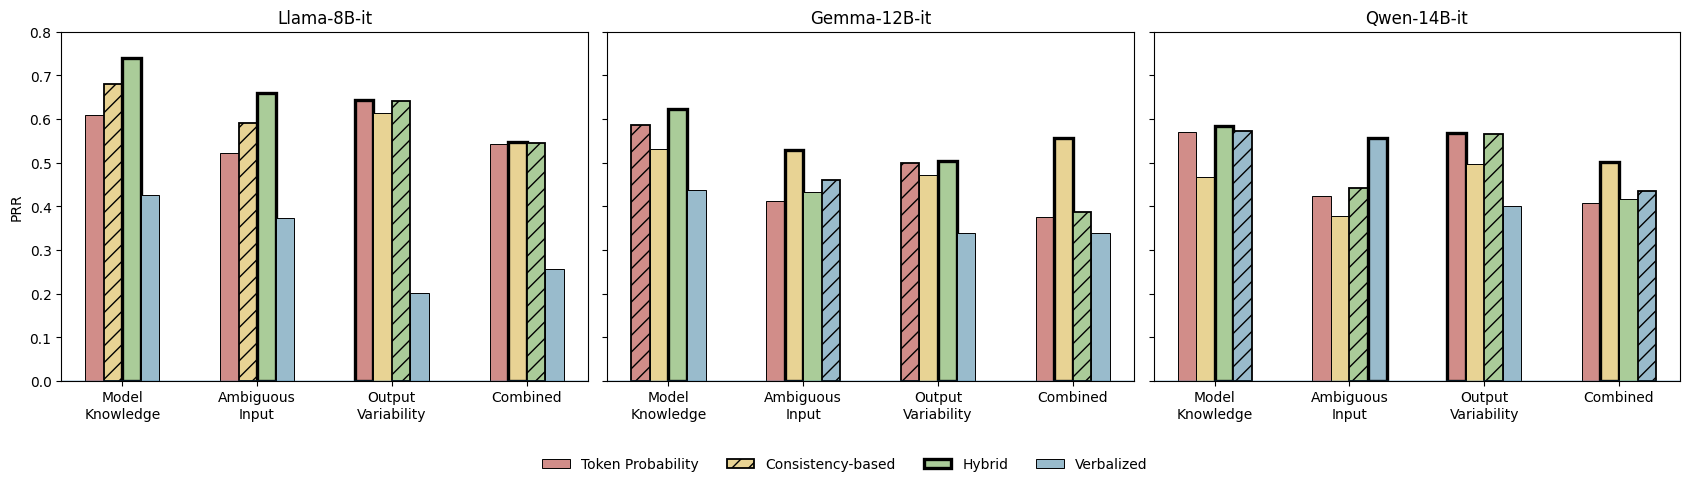

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# -----------------------
# Config
# -----------------------
MODEL_FILES = {
    "Llama-8B-it":  "results/llama8bit_prr_results_0.75_reject_with_NLI_and_verb.csv",
    "Gemma-12B-it": "results/gemma12bit_prr_results_0.75_reject_with_NLI_and_verb.csv",
    "Qwen-14B-it":  "results/qwen14bit_prr_results_0.75_reject_with_NLI_and_verb.csv",
}

# Your "type" column values in the CSVs:
TYPES = ["single", "single_ambi", "multi", "combined"]
TYPE_LABELS = ["Model\nKnowledge", "Ambiguous\nInput", "Output\nVariability", "Combined"]

FAMILIES = ["TP", "CONS", "HYBRID", "VERB"]

PALETTE = {
    "TP": "#D18D89",
    "CONS": "#E8D394",
    "HYBRID": "#AACC99",
    "VERB": "#99BBCC",
}

FAMILY_LABELS = {
    "TP": "Token Probability",
    "CONS": "Consistency-based",
    "HYBRID": "Hybrid",
    "VERB": "Verbalized",
}

# -----------------------
# Family definitions (from your commented groups)
# -----------------------
TP_METHODS = [
    "MaximumSequenceProbability",
    "Perplexity",
    "MeanTokenEntropy",
    "MeanPointwiseMutualInformation",
    "MonteCarloSequenceEntropy",
    "MonteCarloNormalizedSequenceEntropy",
]

CONS_METHODS = [
    "Consistency",
    "NumSemSets",
    "EigValLaplacian_NLI_score_entail",
    "DegMat_NLI_score_entail",
    "Eccentricity_NLI_score_entail",
]

HYBRID_METHODS = [
    "SemanticEntropy",
    "LUQ",
    "SAR",
    "SemanticDensity",
    "CocoaMSP",
    "CocoaPPL",
    "CocoaMTE",
]

VERB_METHODS = [
    "PTrue",
    "UEVerbalized2S",
]

# Build method -> family lookup
METHOD_TO_FAMILY = {}
for m in TP_METHODS: METHOD_TO_FAMILY[m] = "TP"
for m in CONS_METHODS: METHOD_TO_FAMILY[m] = "CONS"
for m in HYBRID_METHODS: METHOD_TO_FAMILY[m] = "HYBRID"
for m in VERB_METHODS: METHOD_TO_FAMILY[m] = "VERB"


# -----------------------
# Helpers
# -----------------------
def load_one_model(csv_path: str, model_name: str) -> pd.DataFrame:
    p = Path(csv_path)
    if not p.exists():
        # fallback for notebooks where files are staged under /mnt/data
        p2 = Path("/mnt/data") / csv_path
        if p2.exists():
            p = p2
        else:
            raise FileNotFoundError(f"Could not find: {csv_path} (also tried {p2})")

    df = pd.read_csv(p)

    # Expect columns: method, prr, type
    needed = {"method", "prr", "type"}
    missing = needed - set(df.columns)
    if missing:
        raise ValueError(f"{csv_path} missing columns: {missing}")

    df = df.copy()
    df["model"] = model_name

    # Keep only known types (and keep ordering)
    df = df[df["type"].isin(TYPES)].copy()
    df["type"] = pd.Categorical(df["type"], categories=TYPES, ordered=True)

    # Assign family; drop anything not in our mapping
    df["family"] = df["method"].map(METHOD_TO_FAMILY)
    df = df.dropna(subset=["family"]).copy()

    # Optional: if you want to exclude any NLI methods entirely, uncomment:
    # df = df[~df["method"].str.contains("NLI", case=False, na=False)].copy()

    return df


def best_per_family(df_all: pd.DataFrame) -> pd.DataFrame:
    """
    Returns rows: model, type, family, prr, method (best method within family)
    """
    best = (
        df_all.sort_values(["model", "type", "family", "prr"], ascending=[True, True, True, False])
             .groupby(["model", "type", "family"], as_index=False)
             .first()
    )
    return best


# -----------------------
# Load + summarize
# -----------------------
df_all = pd.concat(
    [load_one_model(path, model) for model, path in MODEL_FILES.items()],
    ignore_index=True
)

best = best_per_family(df_all)

# Wide PRR table (for bar heights)
wide_prr = (
    best.pivot_table(index=["model", "type"], columns="family", values="prr", aggfunc="first")
        .reindex(columns=FAMILIES)
        .reset_index()
)

# Wide method-name table (for labels above bars)
wide_method = (
    best.pivot_table(index=["model", "type"], columns="family", values="method", aggfunc="first")
        .reindex(columns=FAMILIES)
        .reset_index()
)

# -----------------------
# Plot
# -----------------------
MODELS = list(MODEL_FILES.keys())
fig, axes = plt.subplots(1, len(MODELS), figsize=(17, 4.8), sharey=True)

if len(MODELS) == 1:
    axes = [axes]

bar_width = 0.22
within_group_spacing = 1.0
group_gap = 1.6
x = np.arange(len(TYPES)) * group_gap

for ax, model in zip(axes, MODELS):
    sub_prr = (
        wide_prr[wide_prr["model"] == model]
        .set_index("type")
        .loc[TYPES]
        .reset_index()
    )

    sub_meth = (
        wide_method[wide_method["model"] == model]
        .set_index("type")
        .loc[TYPES]
        .reset_index()
    )

    # Determine best & second-best family per type (row)
    best_fam = []
    second_fam = []
    for _, r in sub_prr.iterrows():
        scores = r[FAMILIES].astype(float)

        # If some families are missing (NaN), sort_values puts NaN last automatically
        order = scores.sort_values(ascending=False).index.tolist()

        # Guard: if fewer than 2 non-NaN families
        non_nan = [f for f in order if pd.notna(scores[f])]
        best_fam.append(non_nan[0] if len(non_nan) >= 1 else None)
        second_fam.append(non_nan[1] if len(non_nan) >= 2 else None)

    # Plot family bars
    for i, fam in enumerate(FAMILIES):
        heights = sub_prr[fam].to_numpy(dtype=float)

        bars = ax.bar(
            x + (i - (len(FAMILIES)-1)/2) * bar_width * within_group_spacing,
            heights,
            width=bar_width,
            color=PALETTE[fam],
            edgecolor="black",
            linewidth=0.7,
            label=FAMILY_LABELS[fam],
        )

        # Highlight best / second-best per type
        for j, b in enumerate(bars):
            if best_fam[j] == fam:
                b.set_linewidth(2.4)     # best: thick outline
            elif second_fam[j] == fam:
                b.set_hatch("//")        # second: hatch
                b.set_linewidth(1.3)

            # Optional: method name above each bar (skip NaN)
            # method_name = sub_meth.loc[j, fam] if fam in sub_meth.columns else None
            # if pd.notna(heights[j]) and pd.notna(method_name):
            #     ax.text(
            #         b.get_x() + b.get_width()/2,
            #         heights[j] + 0.01,
            #         str(method_name),
            #         ha="center",
            #         va="bottom",
            #         rotation=90,
            #         fontsize=8
            #     )

    ax.set_title(model)
    ax.set_xticks(x)
    ax.set_xticklabels(TYPE_LABELS)
    ax.axhline(0, linewidth=1)
    ax.set_ylim(0.0, 0.8)

axes[0].set_ylabel("PRR")

# Single legend (bottom)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=len(FAMILIES),
    frameon=False
)

fig.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig(
    "prr_summary.pdf",
    bbox_inches="tight",
    dpi=300
)
plt.show()


In [6]:
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ── 1. Derive ground-truth labels from quality annotations + decision ──────────
#
# Single answer:   decision=1 (correct)      → none
#                  decision=0 (incorrect)     → model_knowledge
# Multi-answer:    decision=1 (correct)       → output_variability
#                  decision=0 (incorrect)     → model_knowledge
# Ambiguous input: decision=1 (clarification) → none
#                  decision=0 (answered)      → input_ambiguity

def derive_labels(decisions, scenario):
    labels = []
    for d in decisions:
        if scenario == 'Single answer':
            labels.append('none' if d == 1 else 'model_knowledge')
        elif scenario == 'Multi-answer':
            labels.append('output_variability' if d == 1 else 'model_knowledge')
        elif scenario == 'Ambiguous input':
            labels.append('none' if d == 1 else 'input_ambiguity')
    return labels

gt_single = derive_labels(man_single.gen_metrics[('sequence', 'decision')], 'Single answer')
gt_multi  = derive_labels(man_multi.gen_metrics[('sequence', 'decision')],  'Multi-answer')
gt_ambi   = derive_labels(man_ambi.gen_metrics[('sequence', 'decision')],   'Ambiguous input')

# ── 2. Load GPT-4.1 predictions ───────────────────────────────────────────────

ann = pd.read_csv('/home/maiya.goloburda/why_dont_know/source_annotation.csv')
ann = ann.sort_values('id').reset_index(drop=True)

# ── 3. Align (annotation may cover a subset of rows) ─────────────────────────

n = min(len(ann), len(gt_single), len(gt_multi), len(gt_ambi))
ann = ann.iloc[:n]

pred_s1 = ann['s1_label'].tolist()
pred_s2 = ann['s2_label'].tolist()
pred_s3 = ann['s3_label'].tolist()

gt_s1 = gt_single[:n]
gt_s2 = gt_multi[:n]
gt_s3 = gt_ambi[:n]

# ── 4. Compare per scenario ───────────────────────────────────────────────────

scenarios = [
    ('S1 — single answer   (expected: none / model_knowledge)',        gt_s1, pred_s1),
    ('S2 — multi-answer    (expected: output_variability / model_knowledge)', gt_s2, pred_s2),
    ('S3 — ambiguous input (expected: input_ambiguity / none)',        gt_s3, pred_s3),
]

for title, gt, pred in scenarios:
    print(f"\n{'='*65}")
    print(f"  {title}")
    print(f"{'='*65}")
    labels = sorted(set(gt) | set(pred))
    print(f"Accuracy: {accuracy_score(gt, pred):.3f}  (n={len(gt)})")
    print("\nClassification report:")
    print(classification_report(gt, pred, labels=labels, zero_division=0))
    print("Confusion matrix  (rows = ground truth, cols = predicted):")
    cm = pd.DataFrame(
        confusion_matrix(gt, pred, labels=labels),
        index=[f'GT: {l}' for l in labels],
        columns=[f'Pred: {l}' for l in labels],
    )
    print(cm.to_string())



  S1 — single answer   (expected: none / model_knowledge)
Accuracy: 0.186  (n=539)

Classification report:
                    precision    recall  f1-score   support

   input_ambiguity       0.00      0.00      0.00         0
   model_knowledge       0.06      1.00      0.11        28
              none       1.00      0.14      0.25       511
output_variability       0.00      0.00      0.00         0

          accuracy                           0.19       539
         macro avg       0.27      0.29      0.09       539
      weighted avg       0.95      0.19      0.24       539

Confusion matrix  (rows = ground truth, cols = predicted):
                        Pred: input_ambiguity  Pred: model_knowledge  Pred: none  Pred: output_variability
GT: input_ambiguity                         0                      0           0                         0
GT: model_knowledge                         0                     28           0                         0
GT: none                     

In [ ]:
# ── Combined accuracy + confusion matrix across all three scenarios ───────────

ALL_LABELS = ['none', 'model_knowledge', 'output_variability', 'input_ambiguity']

gt_all   = gt_s1   + gt_s2   + gt_s3
pred_all = pred_s1 + pred_s2 + pred_s3

print(f"Combined accuracy: {accuracy_score(gt_all, pred_all):.3f}  (n={len(gt_all)})")
print("\nClassification report:")
print(classification_report(gt_all, pred_all, labels=ALL_LABELS, zero_division=0))
print("Confusion matrix  (rows = ground truth, cols = predicted):")
cm_all = pd.DataFrame(
    confusion_matrix(gt_all, pred_all, labels=ALL_LABELS),
    index=[f'GT: {l}' for l in ALL_LABELS],
    columns=[f'Pred: {l}' for l in ALL_LABELS],
)
print(cm_all.to_string())
